In [67]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import torch
import torch.nn as nn
from torch.nn import functional as F

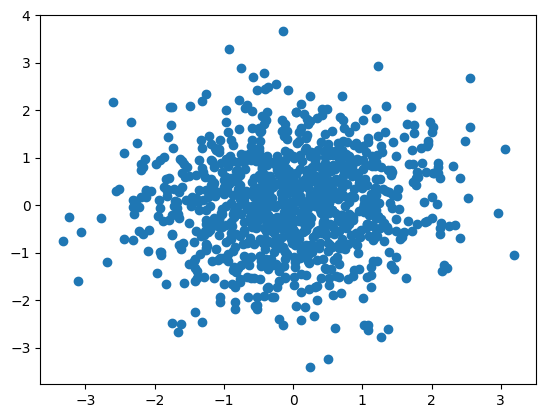

In [68]:
a = torch.randn(1000, 2, dtype=torch.float32)
x_data = a[:, 0]
y_data = a[:, 1]
x_0 = a # noise x in time 0
plt.scatter(x_data, y_data)
plt.show()

In [69]:
moon = make_moons(n_samples=1000, noise=0.1)
moon = moon[0]
x_moon_data = moon[:, 0]
y_moon_data = moon[:, 1]
x_1 = torch.tensor(moon, dtype=torch.float32) # change tuple moon to tensor targets x_1 in time 1
print(x_1)

tensor([[ 0.4583,  0.9566],
        [-1.0308,  0.2018],
        [ 2.0018,  0.3852],
        ...,
        [ 0.6387, -0.3921],
        [ 0.6376,  0.8444],
        [ 0.5611,  0.8215]])


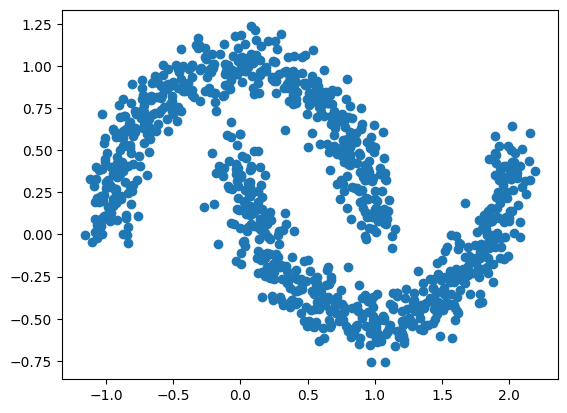

In [70]:
x = x_moon_data
y = y_moon_data
plt.scatter(x, y)
plt.show()

In [60]:
n_points, n_axis = x_0.shape
print(n_points, n_axis)
time = torch.rand(n_points, 1)
x = torch.cat([x_0, time], dim=1) 
print(x.shape)

1000 2
torch.Size([1000, 3])


In [61]:
class CNFs(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        x_t = self.net(x)
        return x_t
    

In [62]:
model = CNFs()
x_t = model(x_0)
loss = F.mse_loss(x_t, x_1)
loss

tensor(0.7810, grad_fn=<MseLossBackward0>)

In [63]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for step in range(250000):
    optimizer.zero_grad()
    x_t = model(x_0)
    loss = F.mse_loss(x_t, x_1)
    loss.backward()
    optimizer.step()
    if step % 10000 == 0:
        print(f"step {step} | loss {loss.item():.4f}")

step 0 | loss 0.7810
step 10000 | loss 0.0883
step 20000 | loss 0.0198
step 30000 | loss 0.0043
step 40000 | loss 0.0026
step 50000 | loss 0.0006
step 60000 | loss 0.0019
step 70000 | loss 0.0003
step 80000 | loss 0.0010
step 90000 | loss 0.0001
step 100000 | loss 0.0000
step 110000 | loss 0.0016
step 120000 | loss 0.0004
step 130000 | loss 0.0000
step 140000 | loss 0.0001
step 150000 | loss 0.0010
step 160000 | loss 0.0000
step 170000 | loss 0.0000
step 180000 | loss 0.0001
step 190000 | loss 0.0000
step 200000 | loss 0.0001
step 210000 | loss 0.0002
step 220000 | loss 0.0005
step 230000 | loss 0.0000
step 240000 | loss 0.0000


<function matplotlib.pyplot.show(close=None, block=None)>

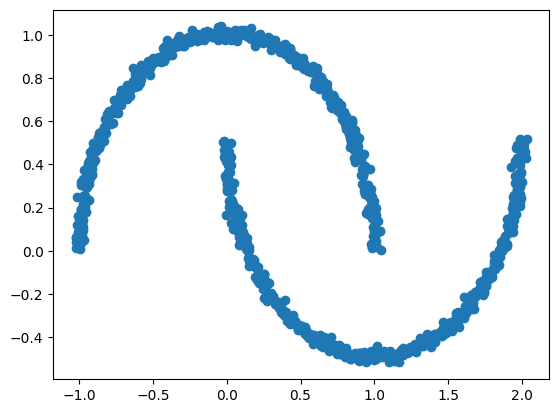

In [64]:
x_final = x_t[:, 0].detach().numpy()
y_final = x_t[:, 1].detach().numpy()
plt.scatter(x_final, y_final)
plt.show

To prevent the model just print the shape just it's lernt, we need to push noise in and apply the model to predict the moon without cheating

<function matplotlib.pyplot.show(close=None, block=None)>

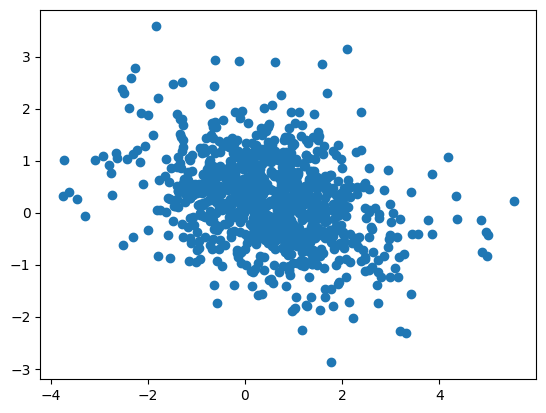

In [ ]:
x_new = torch.randn(1000, 2)

with torch.no_grad():
    x_t = model(x_new)
    
x_final = x_t[:, 0].detach().numpy()
y_final = x_t[:, 1].detach().numpy()
plt.scatter(x_final, y_final)
plt.show()